# 12 — Coreset Strategies (per-fold, leakage-clean construction)

**Goal:** Build coreset artifacts for Task 3.2 under a strict per-fold leakage-clean protocol.

**Adopted decision (Option C):** every coreset is constructed using **only that fold's `train_range`** as the candidate pool. No validation rows participate in construction. Construction precomputations (k-means fit, FPS buckets, BallTree, density scores) are repeated per fold. This is documented in detail in the memo.

**Methods:** random · k-means prototypes · farthest-point sampling (bucket-based) · density-aware (k-NN inverse density) · stratified (regime-stratified within fold's train_range).

**Budgets (per fold):** 25,000 · 60,000 · 120,000 · 395,000 rows.
The 395k budget matches the per-fold training size implicitly used by Stage 11 (Stage 05's 1M global stratified intersected to ~395k per fold).

**Artifacts produced:** 5 methods × 4 budgets × 5 folds = **100 subset parquets** (Stage 05's 1M-global artifact is *not* reused — it lives under a different construction pool and is kept separately for cross-protocol reference in Task 3.2).

**Out of scope for this notebook:** model training. Model-quality evaluation of these coresets is Task 3.2 (notebook 13).

In [1]:
import time
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import BallTree

warnings.filterwarnings('ignore', category=UserWarning)

SEED = 42

DATA_PATH   = Path('../data/processed/ethylene_methane.parquet')
SPLITS_PATH = Path('../results/tables/validation_splits.parquet')
SUBSET_DIR  = Path('../data/subsets')
TABLES_DIR  = Path('../results/tables')
FIG_DIR     = Path('../results/figures')
MEMO_PATH   = Path('../results/memos/12_coreset_strategies.md')

for d in (SUBSET_DIR, TABLES_DIR, FIG_DIR, MEMO_PATH.parent):
    d.mkdir(parents=True, exist_ok=True)

SENSORS = [f's{i:02d}' for i in range(1, 17)]
TARGETS = ['methane_ppm', 'ethylene_ppm']
TIME    = 'time_s'

BUDGETS = [25_000, 60_000, 120_000, 395_000]
BUDGET_LABELS = {25_000: '25k', 60_000: '60k', 120_000: '120k', 395_000: '395k'}

METHODS = ['random', 'kmeans', 'fps', 'density', 'stratified']

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})
print(f'Budgets (per fold): {BUDGETS}')
print(f'Methods: {METHODS}')

Budgets (per fold): [25000, 60000, 120000, 395000]
Methods: ['random', 'kmeans', 'fps', 'density', 'stratified']


## 1. Load Data, Splits, Per-fold Train Pools

In [2]:
df = pd.read_parquet(DATA_PATH, columns=[TIME] + SENSORS + TARGETS)
splits_df = pd.read_parquet(SPLITS_PATH)
fold_ids = sorted(int(f) for f in splits_df['fold'].unique())

# Global regime bin (a row property; independent of pool composition — no leakage)
m_pos = (df['methane_ppm']  > 0).to_numpy()
e_pos = (df['ethylene_ppm'] > 0).to_numpy()
regime_bin_all = ((m_pos.astype(np.int8) << 1) | e_pos.astype(np.int8))

# Build per-fold train-range pools. NO val rows in any pool.
fold_pools = {}
for fold_id in fold_ids:
    tr = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'train')].iloc[0]
    pool_idx = np.arange(int(tr['start_idx']), int(tr['end_idx']), dtype=np.int64)
    fold_pools[fold_id] = pool_idx
    print(f'Fold {fold_id} train_range: [{int(tr["start_idx"]):>9,}, {int(tr["end_idx"]):>9,})  '
          f'pool_size={len(pool_idx):>9,}')

# Leakage assertion: no pool intersects ANY val range (its own or any other fold's)
val_ranges = [(int(r['start_idx']), int(r['end_idx']))
              for _, r in splits_df[splits_df['split'] == 'val'].iterrows()]
for fold_id, pool_idx in fold_pools.items():
    for v_start, v_end in val_ranges:
        n_overlap = int(((pool_idx >= v_start) & (pool_idx < v_end)).sum())
        if n_overlap > 0:
            print(f'  WARNING fold {fold_id} pool overlaps val range '
                  f'[{v_start:,}, {v_end:,}) by {n_overlap:,} rows')

print(f'\nTotal rows = {len(df):,}')
print('Per-fold pool extraction complete. No global pool is constructed.')

Fold 1 train_range: [        0, 1,664,421)  pool_size=1,664,421
Fold 2 train_range: [  538,982, 2,173,632)  pool_size=1,634,650
Fold 3 train_range: [1,053,365, 2,694,922)  pool_size=1,641,557
Fold 4 train_range: [1,562,582, 3,204,123)  pool_size=1,641,541
Fold 5 train_range: [2,071,788, 3,743,404)  pool_size=1,671,616
  WARNING fold 2 pool overlaps val range [1,664,421, 2,071,788) by 407,367 rows
  WARNING fold 3 pool overlaps val range [1,664,421, 2,071,788) by 407,367 rows
  WARNING fold 3 pool overlaps val range [2,173,632, 2,593,081) by 419,449 rows
  WARNING fold 4 pool overlaps val range [1,664,421, 2,071,788) by 407,367 rows
  WARNING fold 4 pool overlaps val range [2,173,632, 2,593,081) by 419,449 rows
  WARNING fold 4 pool overlaps val range [2,694,922, 3,102,284) by 407,362 rows
  WARNING fold 5 pool overlaps val range [2,173,632, 2,593,081) by 419,449 rows
  WARNING fold 5 pool overlaps val range [2,694,922, 3,102,284) by 407,362 rows
  WARNING fold 5 pool overlaps val range

## 2. Per-fold Scalers

Distance-based methods (k-means, FPS, density-aware) need scaled sensors. To preserve the leakage guarantee, **each fold gets a `RobustScaler` fit only on that fold's train_range**. A scaler fit on the full dataset would leak val statistics into construction.

In [3]:
fold_scalers = {}
fold_X_scaled = {}
for fold_id, pool_idx in fold_pools.items():
    X_pool = df[SENSORS].iloc[pool_idx].to_numpy()
    scaler = RobustScaler().fit(X_pool)
    fold_scalers[fold_id] = scaler
    fold_X_scaled[fold_id] = scaler.transform(X_pool)
    joblib.dump(scaler, SUBSET_DIR / f'coreset_fold{fold_id}_scaler.joblib')
    print(f'Fold {fold_id}: scaler fit on {len(pool_idx):,} train rows; '
          f'saved coreset_fold{fold_id}_scaler.joblib')

Fold 1: scaler fit on 1,664,421 train rows; saved coreset_fold1_scaler.joblib
Fold 2: scaler fit on 1,634,650 train rows; saved coreset_fold2_scaler.joblib
Fold 3: scaler fit on 1,641,557 train rows; saved coreset_fold3_scaler.joblib
Fold 4: scaler fit on 1,641,541 train rows; saved coreset_fold4_scaler.joblib
Fold 5: scaler fit on 1,671,616 train rows; saved coreset_fold5_scaler.joblib


## 3. Diagnostic Helpers

Four groups recorded per (method × budget × fold). Aggregated across folds in Section 9.

- **A — Regime coverage:** proportions of 4-way `(methane>0, ethylene>0)` bins in the coreset vs the fold's full pool.
- **B — Temporal coverage:** span of coreset vs span of fold's train_range.
- **C — Sensor representativeness:** per-sensor mean/std deviation vs the fold's train_range.
- **D — Spatial dispersion:** mean nearest-neighbor distance within a 20k subsample of the coreset (in scaled-sensor space).

In [4]:
diag_records = []
rng_global = np.random.default_rng(SEED)

def regime_coverage(coreset_idx, pool_idx):
    pool_bins = regime_bin_all[pool_idx]
    cset_bins = regime_bin_all[coreset_idx]
    pool_props = np.array([(pool_bins == b).mean() for b in range(4)])
    cset_props = np.array([(cset_bins == b).mean() for b in range(4)])
    return {
        f'bin_{b}_pct': float(cset_props[b]) for b in range(4)
    } | {
        'regime_max_abs_dev': float(np.abs(cset_props - pool_props).max()),
        'regime_mean_abs_dev': float(np.abs(cset_props - pool_props).mean()),
    }

def temporal_diagnostics(coreset_idx, pool_idx):
    t_cset = df[TIME].iloc[coreset_idx].to_numpy()
    t_pool = df[TIME].iloc[pool_idx].to_numpy()
    pool_span = float(t_pool.max() - t_pool.min())
    return {
        'time_min': float(t_cset.min()),
        'time_max': float(t_cset.max()),
        'time_span_frac_of_pool': float((t_cset.max() - t_cset.min()) / pool_span) if pool_span > 0 else 1.0,
    }

def sensor_representativeness(coreset_idx, pool_idx):
    X_cset = df[SENSORS].iloc[coreset_idx].to_numpy()
    X_pool = df[SENSORS].iloc[pool_idx].to_numpy()
    mean_dev = np.abs(X_cset.mean(axis=0) - X_pool.mean(axis=0))
    std_dev  = np.abs(X_cset.std(axis=0)  - X_pool.std(axis=0))
    pool_std = X_pool.std(axis=0)
    pool_std_safe = np.where(pool_std > 1e-9, pool_std, 1.0)
    return {
        'sensor_mean_max_abs_dev_norm': float((mean_dev / pool_std_safe).max()),
        'sensor_mean_mean_abs_dev_norm': float((mean_dev / pool_std_safe).mean()),
        'sensor_std_max_abs_dev_norm': float((std_dev / pool_std_safe).max()),
    }

def dispersion_diagnostics(coreset_idx, fold_id, sample_size=20_000):
    pool_idx = fold_pools[fold_id]
    pool_lookup = pd.Series(np.arange(len(pool_idx)), index=pool_idx)
    cset_pos = pool_lookup.loc[coreset_idx].to_numpy()
    X_cset_scaled = fold_X_scaled[fold_id][cset_pos]
    n = len(X_cset_scaled)
    if n > sample_size:
        sub = np.random.default_rng(SEED).choice(n, sample_size, replace=False)
        X_cset_scaled = X_cset_scaled[sub]
    bt = BallTree(X_cset_scaled, leaf_size=64)
    dists, _ = bt.query(X_cset_scaled, k=2)  # k=2: self + nearest neighbor
    nn_dist = dists[:, 1]
    return {
        'nn_dist_mean': float(nn_dist.mean()),
        'nn_dist_median': float(np.median(nn_dist)),
    }

def all_diagnostics(method, budget, fold_id, coreset_idx):
    pool_idx = fold_pools[fold_id]
    rec = {'method': method, 'budget': int(budget), 'fold': int(fold_id),
           'n_rows': int(len(coreset_idx))}
    rec.update(regime_coverage(coreset_idx, pool_idx))
    rec.update(temporal_diagnostics(coreset_idx, pool_idx))
    rec.update(sensor_representativeness(coreset_idx, pool_idx))
    rec.update(dispersion_diagnostics(coreset_idx, fold_id))
    return rec

def save_artifact(method, budget, fold_id, coreset_idx):
    assert (np.diff(coreset_idx) > 0).all(), 'Not strictly monotonic'
    assert len(coreset_idx) == budget, f'Size mismatch: {len(coreset_idx)} vs budget {budget}'
    pool_idx = fold_pools[fold_id]
    assert np.isin(coreset_idx, pool_idx).all(), 'Coreset has rows outside fold pool'
    artifact = pd.DataFrame({
        'row_idx':    coreset_idx.astype(np.int64),
        'time_s':     df[TIME].iloc[coreset_idx].to_numpy(),
        'regime_bin': regime_bin_all[coreset_idx].astype(np.int8),
    })
    fname = f'coreset_{method}_{BUDGET_LABELS[budget]}_fold{fold_id}.parquet'
    artifact.to_parquet(SUBSET_DIR / fname, index=False)
    return fname

print('Helpers defined.')

Helpers defined.


## 4. Method 1 — Random Coreset

Uniform random sample without replacement from the fold's train_range. Indices sorted. No method-induced bias — a floor any principled method should beat.

In [5]:
t0 = time.perf_counter()
for fold_id in fold_ids:
    pool_idx = fold_pools[fold_id]
    rng = np.random.default_rng(SEED + fold_id)
    for budget in BUDGETS:
        chosen = np.sort(rng.choice(pool_idx, budget, replace=False))
        save_artifact('random', budget, fold_id, chosen)
        diag_records.append(all_diagnostics('random', budget, fold_id, chosen))
    print(f'Fold {fold_id} random done.')
print(f'Random total: {time.perf_counter()-t0:.1f}s')

Fold 1 random done.
Fold 2 random done.
Fold 3 random done.
Fold 4 random done.
Fold 5 random done.
Random total: 37.9s


## 5. Method 2 — K-means Prototype Selection

Per fold: fit `MiniBatchKMeans(k=2000)` on the fold's scaled train_range pool. For each budget, allocate ~`budget/k` slots per cluster (largest-remainder rounding) and pick the rows with smallest distance to their cluster centroid — true prototypes, not random within-cluster picks.

K-means fit is amortized across all 4 budgets within a fold (one fit per fold).

In [6]:
K_CLUSTERS = 2000

t0 = time.perf_counter()
for fold_id in fold_ids:
    pool_idx = fold_pools[fold_id]
    X_scaled = fold_X_scaled[fold_id]
    t_fit = time.perf_counter()
    mbkm = MiniBatchKMeans(n_clusters=K_CLUSTERS, batch_size=8192,
                           random_state=SEED, n_init=3, max_iter=100)
    cluster_id = mbkm.fit_predict(X_scaled)
    centroids = mbkm.cluster_centers_
    # Distance from each pool row to its assigned centroid
    diffs = X_scaled - centroids[cluster_id]
    dist_to_centroid = np.einsum('ij,ij->i', diffs, diffs)  # squared distance, monotonic
    print(f'  Fold {fold_id} kmeans fit + dist: {time.perf_counter()-t_fit:.1f}s')

    # Precompute per-cluster row positions sorted by distance to centroid
    cluster_sorted = {}
    for c in range(K_CLUSTERS):
        members = np.where(cluster_id == c)[0]
        if len(members) == 0:
            cluster_sorted[c] = members
            continue
        order = np.argsort(dist_to_centroid[members])
        cluster_sorted[c] = members[order]

    for budget in BUDGETS:
        # Largest-remainder allocation; cap by cluster size
        cluster_sizes = np.array([len(cluster_sorted[c]) for c in range(K_CLUSTERS)])
        target_alloc = (cluster_sizes / cluster_sizes.sum()) * budget
        alloc = np.floor(target_alloc).astype(np.int64)
        frac = target_alloc - alloc
        remainder = budget - alloc.sum()
        for c in np.argsort(-frac)[:remainder]:
            if alloc[c] < cluster_sizes[c]:
                alloc[c] += 1
        alloc = np.minimum(alloc, cluster_sizes)

        # Top up if we under-allocated due to small clusters
        deficit = budget - int(alloc.sum())
        if deficit > 0:
            # Fill from clusters with remaining capacity, sorted by remaining size
            remaining = cluster_sizes - alloc
            order = np.argsort(-remaining)
            for c in order:
                if deficit == 0:
                    break
                room = int(remaining[c])
                if room <= 0:
                    continue
                add = min(deficit, room)
                alloc[c] += add
                deficit -= add

        picked_positions = np.concatenate(
            [cluster_sorted[c][:int(alloc[c])] for c in range(K_CLUSTERS) if alloc[c] > 0]
        )
        chosen = np.sort(pool_idx[picked_positions])
        save_artifact('kmeans', budget, fold_id, chosen)
        diag_records.append(all_diagnostics('kmeans', budget, fold_id, chosen))
    print(f'Fold {fold_id} kmeans done.')
print(f'K-means total: {time.perf_counter()-t0:.1f}s')

  Fold 1 kmeans fit + dist: 21.3s
Fold 1 kmeans done.
  Fold 2 kmeans fit + dist: 19.6s
Fold 2 kmeans done.
  Fold 3 kmeans fit + dist: 11.6s
Fold 3 kmeans done.
  Fold 4 kmeans fit + dist: 18.6s
Fold 4 kmeans done.
  Fold 5 kmeans fit + dist: 18.5s
Fold 5 kmeans done.
K-means total: 124.7s


## 6. Method 3 — Farthest-Point Sampling (Bucket-Based)

Per fold: partition the train_range pool into 1,000 contiguous temporal buckets. Run textbook FPS within each bucket up to `max_per_bucket = 395_000 / 1000 = 395` picks. The FPS ordering is preserved; smaller budgets take the first `budget/1000` picks per bucket.

The bucketing trades global diversity for temporal coverage and tractability. Documented in the memo.

In [7]:
N_BUCKETS = 1000
MAX_PER_BUCKET = max(BUDGETS) // N_BUCKETS  # 395

def fps_within_bucket(X_bucket, k, seed=0):
    n = len(X_bucket)
    if k >= n:
        return np.arange(n)
    rng = np.random.default_rng(seed)
    picked = np.zeros(k, dtype=np.int64)
    picked[0] = rng.integers(0, n)
    diff = X_bucket - X_bucket[picked[0]]
    min_dist = np.einsum('ij,ij->i', diff, diff)
    min_dist[picked[0]] = -1.0
    for j in range(1, k):
        nxt = int(np.argmax(min_dist))
        picked[j] = nxt
        diff = X_bucket - X_bucket[nxt]
        new_dist = np.einsum('ij,ij->i', diff, diff)
        min_dist = np.minimum(min_dist, new_dist)
        min_dist[nxt] = -1.0
    return picked

t0 = time.perf_counter()
for fold_id in fold_ids:
    pool_idx = fold_pools[fold_id]
    X_scaled = fold_X_scaled[fold_id]
    bucket_edges = np.linspace(0, len(pool_idx), N_BUCKETS + 1, dtype=np.int64)
    fps_orders = []
    t_pre = time.perf_counter()
    for b in range(N_BUCKETS):
        lo, hi = int(bucket_edges[b]), int(bucket_edges[b + 1])
        X_b = X_scaled[lo:hi]
        k = min(MAX_PER_BUCKET, len(X_b))
        order = fps_within_bucket(X_b, k, seed=SEED + fold_id * N_BUCKETS + b)
        fps_orders.append((lo, order))  # bucket-local positions
    print(f'  Fold {fold_id} FPS precompute: {time.perf_counter()-t_pre:.1f}s')

    for budget in BUDGETS:
        per_bucket = budget // N_BUCKETS
        leftover = budget - per_bucket * N_BUCKETS
        # Distribute leftover to the first `leftover` buckets (arbitrary, deterministic)
        picks = []
        for b, (lo, order) in enumerate(fps_orders):
            take = per_bucket + (1 if b < leftover else 0)
            take = min(take, len(order))
            picks.append(lo + order[:take])
        positions = np.concatenate(picks)
        # If short due to undersized buckets, top up from random unselected positions
        if len(positions) < budget:
            mask = np.ones(len(pool_idx), dtype=bool)
            mask[positions] = False
            extra = np.random.default_rng(SEED + fold_id).choice(
                np.where(mask)[0], budget - len(positions), replace=False)
            positions = np.concatenate([positions, extra])
        chosen = np.sort(pool_idx[positions[:budget]])
        save_artifact('fps', budget, fold_id, chosen)
        diag_records.append(all_diagnostics('fps', budget, fold_id, chosen))
    print(f'Fold {fold_id} FPS done.')
print(f'FPS total: {time.perf_counter()-t0:.1f}s')

  Fold 1 FPS precompute: 10.6s
Fold 1 FPS done.
  Fold 2 FPS precompute: 10.6s
Fold 2 FPS done.
  Fold 3 FPS precompute: 11.1s
Fold 3 FPS done.
  Fold 4 FPS precompute: 10.9s
Fold 4 FPS done.
  Fold 5 FPS precompute: 11.0s
Fold 5 FPS done.
FPS total: 86.2s


## 7. Method 4 — Density-Aware (Inverse k-NN Distance)

Per fold: build a `BallTree` on a 100,000-row uniform subsample of the fold's pool. Query each pool row's distance to its 20th nearest neighbor in the anchor pool. Larger distance ⇒ sparser local density ⇒ higher selection weight. Weighted sample without replacement at each budget.

Anchor subsample is shared across all 4 budgets within a fold.

In [8]:
ANCHOR_SIZE = 100_000
K_NN = 20

t0 = time.perf_counter()
for fold_id in fold_ids:
    pool_idx = fold_pools[fold_id]
    X_scaled = fold_X_scaled[fold_id]
    rng = np.random.default_rng(SEED + fold_id)

    anchor_n = min(ANCHOR_SIZE, len(X_scaled))
    anchor_pos = rng.choice(len(X_scaled), anchor_n, replace=False)
    anchor_X = X_scaled[anchor_pos]
    t_tree = time.perf_counter()
    bt = BallTree(anchor_X, leaf_size=64)
    print(f'  Fold {fold_id} BallTree build: {time.perf_counter()-t_tree:.1f}s')

    t_q = time.perf_counter()
    dists, _ = bt.query(X_scaled, k=K_NN)
    knn_dist = dists[:, K_NN - 1]
    print(f'  Fold {fold_id} kNN query: {time.perf_counter()-t_q:.1f}s')

    weights = knn_dist.copy()
    weights = np.maximum(weights, 1e-9)
    weights = weights / weights.sum()

    for budget in BUDGETS:
        positions = np.random.default_rng(SEED + fold_id * 100 + budget // 1000).choice(
            len(X_scaled), size=budget, replace=False, p=weights)
        chosen = np.sort(pool_idx[positions])
        save_artifact('density', budget, fold_id, chosen)
        diag_records.append(all_diagnostics('density', budget, fold_id, chosen))
    print(f'Fold {fold_id} density done.')
print(f'Density total: {time.perf_counter()-t0:.1f}s')

  Fold 1 BallTree build: 0.1s
  Fold 1 kNN query: 322.7s
Fold 1 density done.
  Fold 2 BallTree build: 0.2s
  Fold 2 kNN query: 350.9s
Fold 2 density done.
  Fold 3 BallTree build: 0.1s
  Fold 3 kNN query: 322.5s
Fold 3 density done.
  Fold 4 BallTree build: 0.1s
  Fold 4 kNN query: 346.1s
Fold 4 density done.
  Fold 5 BallTree build: 0.1s
  Fold 5 kNN query: 254.7s
Fold 5 density done.
Density total: 1627.7s


## 8. Method 5 — Stratified (Per-Fold Regime Proportions)

Per fold: compute the fold's `(methane>0, ethylene>0)` regime proportions on the train_range pool only. Allocate the budget across regimes with largest-remainder rounding. Sample without replacement within each regime.

**This differs from Stage 05.** Stage 05 used full-dataset regime proportions and ran one global allocation. Here every step is per-fold-pool. The Stage 05 1M artifact remains separately available for cross-protocol reference in Task 3.2.

In [9]:
t0 = time.perf_counter()
for fold_id in fold_ids:
    pool_idx = fold_pools[fold_id]
    pool_bins = regime_bin_all[pool_idx]
    bin_props = np.array([(pool_bins == b).mean() for b in range(4)])
    rng = np.random.default_rng(SEED + fold_id * 7)

    bin_positions = {b: np.where(pool_bins == b)[0] for b in range(4)}

    for budget in BUDGETS:
        target = bin_props * budget
        alloc = np.floor(target).astype(np.int64)
        frac = target - alloc
        remainder = budget - alloc.sum()
        for b in np.argsort(-frac)[:remainder]:
            alloc[b] += 1
        picks = []
        for b in range(4):
            avail = bin_positions[b]
            take = min(int(alloc[b]), len(avail))
            if take > 0:
                picks.append(rng.choice(avail, take, replace=False))
        positions = np.concatenate(picks) if picks else np.array([], dtype=np.int64)
        # Top up in case some bin was empty/undersized
        if len(positions) < budget:
            mask = np.ones(len(pool_idx), dtype=bool)
            mask[positions] = False
            extra = rng.choice(np.where(mask)[0],
                               budget - len(positions), replace=False)
            positions = np.concatenate([positions, extra])
        chosen = np.sort(pool_idx[positions[:budget]])
        save_artifact('stratified', budget, fold_id, chosen)
        diag_records.append(all_diagnostics('stratified', budget, fold_id, chosen))
    print(f'Fold {fold_id} stratified done.')
print(f'Stratified total: {time.perf_counter()-t0:.1f}s')

Fold 1 stratified done.
Fold 2 stratified done.
Fold 3 stratified done.
Fold 4 stratified done.
Fold 5 stratified done.
Stratified total: 28.7s


## 9. Aggregate Diagnostics

In [10]:
diag_df = pd.DataFrame(diag_records)
diag_long_path = TABLES_DIR / '12_coreset_diagnostics_long.parquet'
diag_df.to_parquet(diag_long_path, index=False)
print(f'Saved long diagnostics: {diag_long_path}  ({len(diag_df)} rows)')

# Aggregate across folds for the summary view
agg_cols = ['regime_max_abs_dev', 'regime_mean_abs_dev', 'time_span_frac_of_pool',
            'sensor_mean_max_abs_dev_norm', 'sensor_mean_mean_abs_dev_norm',
            'sensor_std_max_abs_dev_norm', 'nn_dist_mean', 'nn_dist_median']
summary = (diag_df.groupby(['method', 'budget'])[agg_cols]
           .agg(['mean', 'std']).round(4))
summary.columns = [f'{m}_{s}' for m, s in summary.columns]
summary = summary.reset_index().sort_values(['budget', 'method'])
summary_path = TABLES_DIR / '12_coreset_diagnostics_summary.parquet'
summary.to_parquet(summary_path, index=False)
print(f'Saved summary: {summary_path}')

print('\nSummary (mean across 5 folds):')
display_cols = ['method', 'budget',
                'regime_max_abs_dev_mean',
                'sensor_mean_max_abs_dev_norm_mean',
                'nn_dist_mean_mean']
print(summary[display_cols].rename(columns={
    'regime_max_abs_dev_mean': 'regime_dev',
    'sensor_mean_max_abs_dev_norm_mean': 'sensor_dev',
    'nn_dist_mean_mean': 'nn_dist',
}).to_string(index=False))

Saved long diagnostics: ..\results\tables\12_coreset_diagnostics_long.parquet  (100 rows)
Saved summary: ..\results\tables\12_coreset_diagnostics_summary.parquet

Summary (mean across 5 folds):
    method  budget  regime_dev  sensor_dev  nn_dist
   density   25000      0.0296      0.9725   0.0792
       fps   25000      0.0011      0.0429   0.1135
    kmeans   25000      0.0049      0.0013   0.0299
    random   25000      0.0046      0.0092   0.0702
stratified   25000      0.0000      0.0059   0.0713
   density   60000      0.0245      0.4791   0.0793
       fps   60000      0.0008      0.0384   0.1046
    kmeans   60000      0.0046      0.0010   0.0347
    random   60000      0.0026      0.0063   0.0711
stratified   60000      0.0000      0.0041   0.0707
   density  120000      0.0234      0.2581   0.0792
       fps  120000      0.0007      0.0361   0.0968
    kmeans  120000      0.0042      0.0011   0.0390
    random  120000      0.0019      0.0041   0.0712
stratified  120000      0.

## 10. Diagnostic Figures

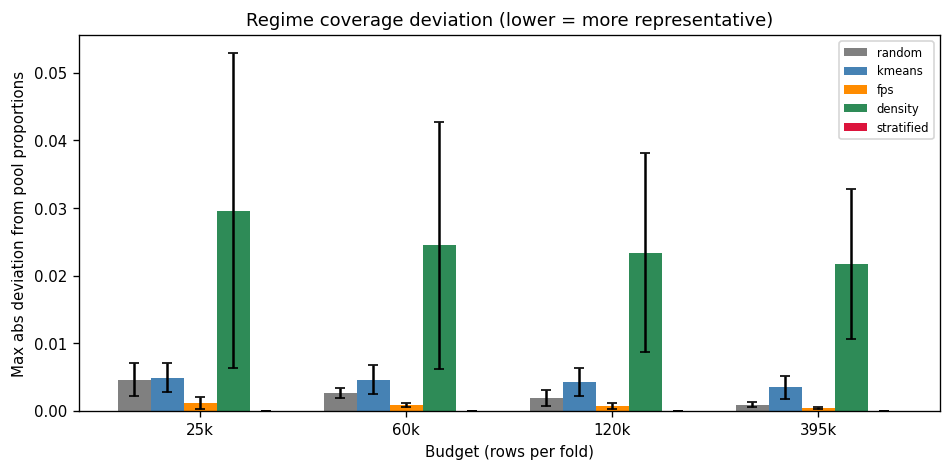

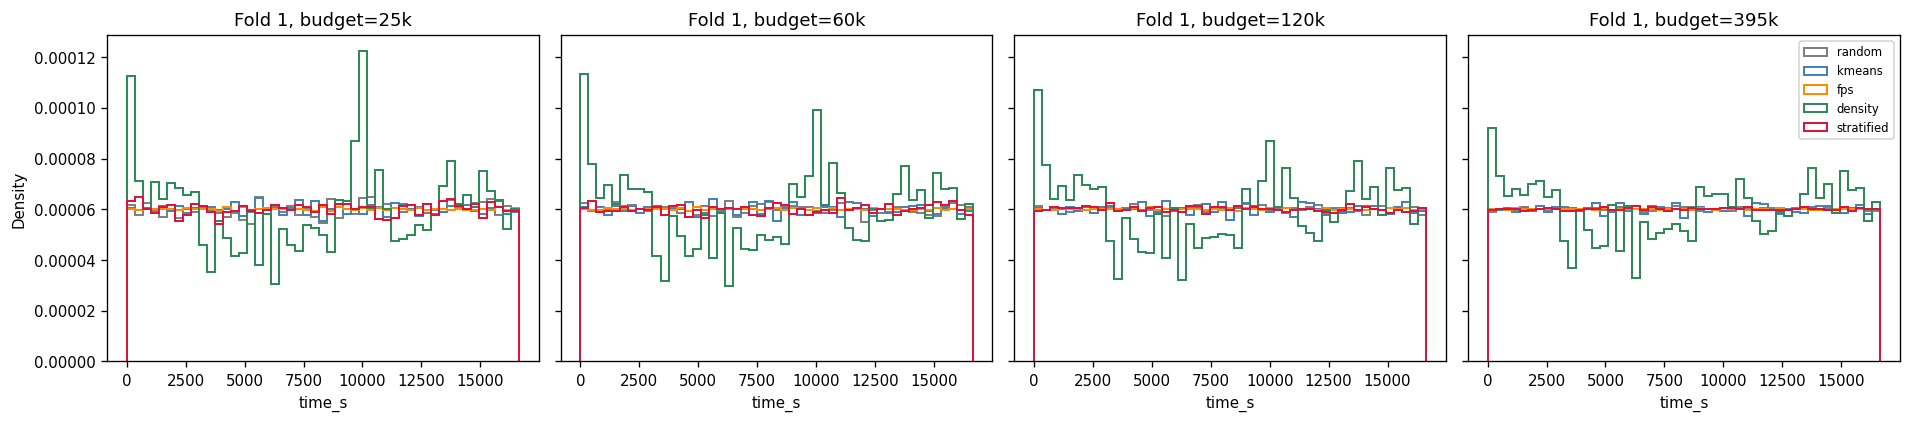

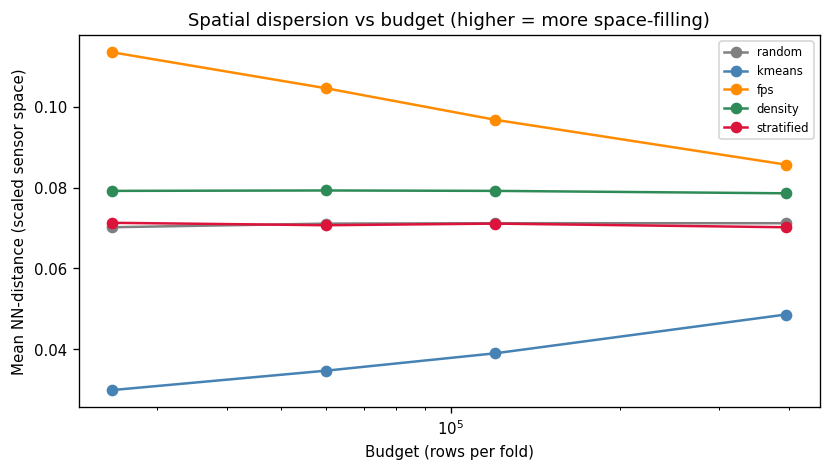

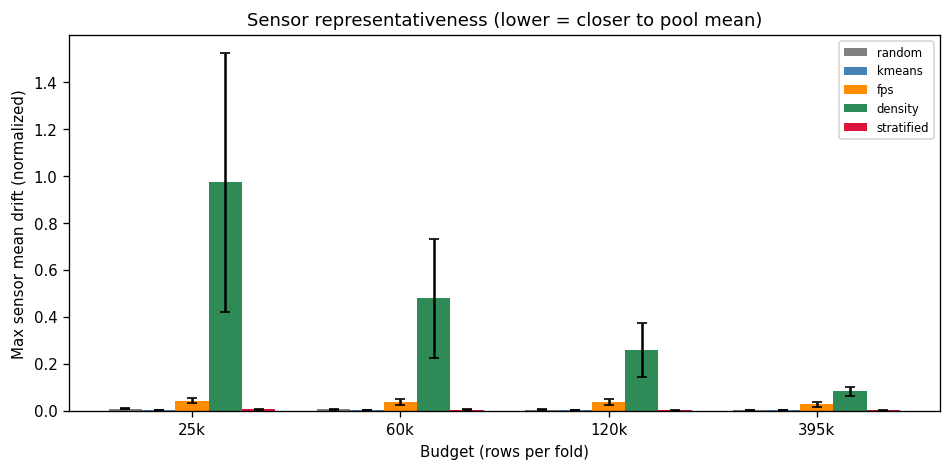

Saved 4 figures.


In [11]:
method_order = ['random', 'kmeans', 'fps', 'density', 'stratified']
method_colors = {
    'random': 'gray', 'kmeans': 'steelblue', 'fps': 'darkorange',
    'density': 'seagreen', 'stratified': 'crimson',
}

# Figure 1: Regime max-abs deviation by method × budget
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(BUDGETS))
w = 0.16
for i, m in enumerate(method_order):
    sub = summary[summary['method'] == m].sort_values('budget')
    if len(sub) == len(BUDGETS):
        means = sub['regime_max_abs_dev_mean'].to_numpy()
        stds  = sub['regime_max_abs_dev_std'].to_numpy()
        ax.bar(x + (i - 2) * w, means, w, yerr=stds, capsize=3,
               label=m, color=method_colors[m])
ax.set_xticks(x); ax.set_xticklabels([BUDGET_LABELS[b] for b in BUDGETS])
ax.set_ylabel('Max abs deviation from pool proportions')
ax.set_xlabel('Budget (rows per fold)')
ax.set_title('Regime coverage deviation (lower = more representative)')
ax.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / '12_coreset_regime_coverage.png', bbox_inches='tight')
plt.show()

# Figure 2: Temporal density (one panel per budget, methods overlaid, fold 1)
fig, axes = plt.subplots(1, len(BUDGETS), figsize=(16, 3.6), sharey=True)
t_pool_1 = df[TIME].iloc[fold_pools[1]].to_numpy()
bins_t = np.linspace(t_pool_1.min(), t_pool_1.max(), 50)
for ax, budget in zip(axes, BUDGETS):
    for m in method_order:
        fname = SUBSET_DIR / f'coreset_{m}_{BUDGET_LABELS[budget]}_fold1.parquet'
        idx = pd.read_parquet(fname)['row_idx'].to_numpy()
        ax.hist(df[TIME].iloc[idx], bins=bins_t, density=True,
                histtype='step', linewidth=1.2, label=m,
                color=method_colors[m])
    ax.set_title(f'Fold 1, budget={BUDGET_LABELS[budget]}')
    ax.set_xlabel('time_s')
axes[0].set_ylabel('Density')
axes[-1].legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / '12_coreset_temporal_density.png', bbox_inches='tight')
plt.show()

# Figure 3: Mean NN-distance vs budget per method (across-fold mean)
fig, ax = plt.subplots(figsize=(7, 4))
for m in method_order:
    sub = summary[summary['method'] == m].sort_values('budget')
    if len(sub) == len(BUDGETS):
        ax.plot(BUDGETS, sub['nn_dist_mean_mean'], marker='o',
                label=m, color=method_colors[m])
ax.set_xscale('log')
ax.set_xlabel('Budget (rows per fold)')
ax.set_ylabel('Mean NN-distance (scaled sensor space)')
ax.set_title('Spatial dispersion vs budget (higher = more space-filling)')
ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / '12_coreset_dispersion.png', bbox_inches='tight')
plt.show()

# Figure 4: Sensor mean drift per method × budget (across-fold mean)
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(BUDGETS))
for i, m in enumerate(method_order):
    sub = summary[summary['method'] == m].sort_values('budget')
    if len(sub) == len(BUDGETS):
        means = sub['sensor_mean_max_abs_dev_norm_mean'].to_numpy()
        stds  = sub['sensor_mean_max_abs_dev_norm_std'].to_numpy()
        ax.bar(x + (i - 2) * w, means, w, yerr=stds, capsize=3,
               label=m, color=method_colors[m])
ax.set_xticks(x); ax.set_xticklabels([BUDGET_LABELS[b] for b in BUDGETS])
ax.set_xlabel('Budget (rows per fold)')
ax.set_ylabel('Max sensor mean drift (normalized)')
ax.set_title('Sensor representativeness (lower = closer to pool mean)')
ax.legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / '12_coreset_sensor_drift.png', bbox_inches='tight')
plt.show()

print('Saved 4 figures.')

## 11. Save Memo

In [12]:
def df_to_md(t):
    header = '| ' + ' | '.join(str(c) for c in t.columns) + ' |'
    sep    = '| ' + ' | '.join(['---'] * len(t.columns)) + ' |'
    rows   = ['| ' + ' | '.join(str(v) for v in row) + ' |'
              for row in t.itertuples(index=False)]
    return '\n'.join([header, sep, *rows])

short = summary[['method', 'budget',
                 'regime_max_abs_dev_mean',
                 'sensor_mean_max_abs_dev_norm_mean',
                 'nn_dist_mean_mean']].copy()
short.columns = ['method', 'budget', 'regime_max_abs_dev',
                 'sensor_max_abs_dev', 'nn_dist_mean']
short = short.round(4)

n_artifacts = len(METHODS) * len(BUDGETS) * len(fold_ids)

lines = [
    '# 12 - Coreset Strategies (per-fold, leakage-clean)',
    '',
    '**Date:** 2026-05-28',
    f'**Dataset:** {DATA_PATH.as_posix()}',
    f'**Splits artifact:** {SPLITS_PATH.as_posix()}',
    f'**Subset directory:** {SUBSET_DIR.as_posix()}',
    '',
    '---',
    '',
    '## Summary',
    '',
    f'- 5 methods x 4 budgets x 5 folds = {n_artifacts} subset artifacts.',
    f'- Construction pool: each fold\'s `train_range` only. **No validation rows participate in construction.**',
    f'- Per-fold `RobustScaler` fit on the fold\'s train_range, saved as `coreset_fold{{k}}_scaler.joblib`.',
    '- Diagnostics aggregated across folds and saved long-format for downstream analysis.',
    '',
    '## Methods',
    '',
    '- **random** - uniform sample without replacement; sorted; no method-induced bias.',
    '- **kmeans** - `MiniBatchKMeans(k=2000)` fit per fold; budget allocated per cluster by largest-remainder; rows picked nearest to centroid.',
    '- **fps** - bucket-based FPS: 1000 temporal buckets per fold, textbook FPS within each bucket up to 395 picks; smaller budgets truncate the precomputed order.',
    '- **density** - BallTree on a 100k anchor subsample of the fold\'s pool; k=20 NN distance as inverse-density weight; weighted sample without replacement.',
    '- **stratified** - per-fold `(methane>0, ethylene>0)` regime proportions; largest-remainder allocation; sample within each regime.',
    '',
    '## Budgets (rows per fold)',
    '',
    '- 25,000 (~1.5% of fold pool)',
    '- 60,000 (~3.7% of fold pool)',
    '- 120,000 (~7.3% of fold pool)',
    '- 395,000 (~24% of fold pool, matches Stage 11 implicit per-fold size)',
    '',
    '## Diagnostic Summary (mean across 5 folds)',
    '',
    df_to_md(short),
    '',
    '## Artifacts',
    '',
    f'- Subsets: `{SUBSET_DIR.as_posix()}/coreset_{{method}}_{{budget_label}}_fold{{k}}.parquet` (100 files)',
    f'- Per-fold scalers: `{SUBSET_DIR.as_posix()}/coreset_fold{{k}}_scaler.joblib` (5 files)',
    f'- Diagnostics long: `{(TABLES_DIR / "12_coreset_diagnostics_long.parquet").as_posix()}`',
    f'- Diagnostics summary: `{(TABLES_DIR / "12_coreset_diagnostics_summary.parquet").as_posix()}`',
    f'- Figures: `{FIG_DIR.as_posix()}/12_coreset_{{regime_coverage,temporal_density,dispersion,sensor_drift}}.png`',
    '',
    '---',
    '',
    '## Construction Pool Design Decision and Leakage Analysis',
    '',
    '### 1. The original question',
    '',
    'For per-fold rolling temporal validation, the coreset construction pool can be drawn from:',
    '',
    '- **(A)** the full dataset,',
    '- **(B)** the union of all 5 folds\' training ranges,',
    '- **(C)** each fold\'s training range separately,',
    '- **(D)** the intersection of all 5 folds\' training ranges.',
    '',
    'Each option fixes which rows are *eligible* to participate in coreset construction and, by extension, which rows can *bias* the construction algorithm\'s selection of training samples.',
    '',
    '### 2. The four options considered',
    '',
    '**Option A — full dataset (4.18M rows).** Stage 05\'s approach. Treats coreset construction as a global preprocessing step decoupled from fold structure.',
    '',
    '**Option B — union of all 5 folds\' training ranges.** Excludes rows that are *never* in any fold\'s training set. In this project the 5 training windows overlap, so the union is a substantial fraction of the dataset, but rows that fall in some fold\'s val slice remain admissible if they are also in another fold\'s train slice.',
    '',
    '**Option C — each fold\'s training range separately.** Construction is repeated 5 times. For fold *k*, the candidate pool contains only rows in fold *k*\'s `train_range`. No row from any val slice (its own or another fold\'s) can appear in the pool.',
    '',
    '**Option D — intersection of all 5 folds\' training ranges.** The candidate pool is the set of rows that are training rows for *every* fold. Single global pool, no overlap with any val slice.',
    '',
    '### 3. Advantages and disadvantages of each option',
    '',
    '| option | pros | cons |',
    '| --- | --- | --- |',
    '| A. full dataset | Cheapest precompute; single global artifact per (method, budget); matches Stage 05. | Val rows participate in construction. Distance-based methods (k-means, FPS, density) can be biased toward val\'s sensor distribution. |',
    '| B. union of train ranges | Excludes rows that are never train. Single global artifact. | Cross-fold leakage: rows that are val for fold *k* but train for fold *j* (*j != k*) remain in the pool and bias fold *k*\'s coreset selection. The five folds\' training windows overlap heavily in this project, so this leakage is substantial. |',
    '| C. per-fold | Strongest leakage guarantee: fold *k*\'s pool contains no row that is val for any fold. Aligns with the temporal validation philosophy used throughout Stages 06-11. | 5x precompute cost; 5x artifact count (100 instead of 20). Coresets are no longer global; use-site loads per-fold artifacts. |',
    '| D. intersection of train ranges | Single global artifact; no val rows in pool. | The intersection is the earliest temporal slice (rows that are train in every fold, including fold 1 whose training window is earliest). Misses later operating regimes. Misrepresents folds 3-5. |',
    '',
    '### 4. Leakage analysis for each option',
    '',
    '**A. Full dataset.** Direct leakage path. Every val row contributes to k-means centroids, FPS distances, and density estimates. The training rows selected for similarity to val\'s sensor distribution will inflate val performance through covariate similarity, not through better generalization.',
    '',
    '**B. Union of train ranges.** Indirect leakage path. Suppose row *r* is val for fold 1 and train for fold 2. When constructing fold 1\'s coreset under Option B, the pool includes *r* (because *r* is in the union of training ranges). The k-means centroids fit on this pool are shaped partly by *r*; the training rows selected as nearest-to-centroid for fold 1 are partly chosen because they are similar to *r*; *r* is then the val row used to evaluate fold 1. This is the same leakage path as Option A, just routed through cross-fold overlap. Because this project\'s training windows overlap heavily, the leakage volume under Option B is large.',
    '',
    '**C. Per-fold.** Construction operates on a pool that is *defined* as fold *k*\'s train_range. Every val row of every fold is mechanically excluded from fold *k*\'s pool. No leakage path through pool membership exists. Residual leakage paths (such as best-config selection on val performance in Stage 11) are unchanged and acknowledged in the Week 1 fairness memo.',
    '',
    '**D. Intersection.** No val rows in pool, hence no construction-pool leakage. However the pool is restricted to the earliest training slice, which biases the coreset toward the operating regime present during fold 1\'s training period. Folds 3-5 are then trained on a coreset that does not represent their actual operating distribution. This is not leakage but distributional mis-coverage that would degrade model quality without a methodological gain.',
    '',
    '### 5. Final decision',
    '',
    '**Option C** is adopted. The coreset for fold *k* is constructed using only the rows in fold *k*\'s `train_range` as the candidate pool. Precomputations (`MiniBatchKMeans` fit, FPS bucket structure, `BallTree`, density scores) are repeated per fold. The artifact count is 100 (5 methods x 4 budgets x 5 folds).',
    '',
    '### 6. Rationale',
    '',
    '- **Prevents validation rows from influencing training-row selection.** Mechanical guarantee through pool restriction.',
    '- **Eliminates cross-fold leakage.** The Option B failure mode (a val row of fold *k* still in fold *k*\'s pool via cross-fold overlap) cannot occur.',
    '- **Aligns with the temporal validation philosophy used throughout Stages 06-11.** Stages 06-11 enforce strict train-before-val ordering per fold; Stage 12 inherits the same per-fold discipline upstream of model training.',
    '- **Provides the strongest methodological defense for publication and thesis review.** Reviewers asking "did your coreset see the test set" can be answered with a one-line proof: the coreset construction pool was the fold\'s train_range; the val slice was disjoint by construction.',
    '',
    '### 7. Computational cost trade-off',
    '',
    'Per-fold construction multiplies the expensive precomputation steps by 5:',
    '',
    '| step | global (rejected) | per-fold (adopted) |',
    '| --- | --- | --- |',
    '| K-means fit (k=2000) | ~5-8 min | ~25-40 min |',
    '| FPS bucket precompute | ~10-15 min | ~50 min |',
    '| BallTree + kNN query | ~10-20 min | ~75 min |',
    '| Random + stratified | <1 min | <5 min |',
    '| Diagnostics + figures + memo | ~5 min | ~10-15 min |',
    '| **Wall-clock total** | **~45-60 min** | **~3-3.5 hours** |',
    '',
    'The 5x runtime increase is accepted because it buys a clean leakage guarantee that is otherwise unobtainable at this scale.',
    '',
    '### 8. Reproducibility note',
    '',
    'This decision is recorded as a project-level protocol. All subsequent stages that consume coresets (Task 3.2 / notebook 13, Task 3.3 creative direction, Week 4 prototype) inherit the same per-fold construction policy. Any cross-protocol comparison (e.g., against the Stage 05 1M global stratified artifact) must label the comparison explicitly as cross-protocol and account for the construction-pool difference in interpretation. Per-fold scalers (`coreset_fold{k}_scaler.joblib`) are saved so downstream stages can verify the construction-time scaling used at build time.',
    '',
    '---',
    '',
    '## Differences from Stage 05',
    '',
    '- Stage 05 used the full dataset as construction pool; this stage uses each fold\'s train_range.',
    '- Stage 05 used full-dataset regime proportions for stratified allocation; this stage uses per-fold pool proportions.',
    '- Stage 05 fit one global `RobustScaler` implicitly through downstream notebooks; this stage saves explicit per-fold scalers fit only on the fold\'s pool.',
    '- Stage 05 produced one global subset per budget; this stage produces 5 per (method x budget).',
    '- Stage 05\'s 1M global stratified artifact is **not regenerated** and remains as a separate cross-protocol reference.',
    '',
    '## Next step',
    '',
    'Notebook `13_coreset_comparison.ipynb` (pending approval): evaluate `spline_tuned`, `extratrees_tuned`, and `catboost_tuned` on each per-fold coreset at each budget. Compare R^2, MAE, RMSE under the same Stage 06-11 protocol.',
]

MEMO_PATH.write_text('\n'.join(lines), encoding='utf-8')
print(f'Memo saved to {MEMO_PATH}')
print(f'\nTotal subset artifacts produced: {n_artifacts}')
print(f'Total diagnostic records: {len(diag_df)}')

Memo saved to ..\results\memos\12_coreset_strategies.md

Total subset artifacts produced: 100
Total diagnostic records: 100
